In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import geopandas
import dask_geopandas
import json
from glob import glob
import time

sys.path.insert(1, os.path.abspath("../.."))
from qtree_index import nestedgrid, mortoncurve
from vectorstore import vectorstore

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
%%time
dataset = 'rooftop_area_growth_projections'
collection_id = 'rooftop-area-growth-projections'

# Stac collection title
collection_title = 'Rooftop Area Growth Projections'

# Stac collection description
description = '''Global high-resolution growth projections dataset for rooftop area consistent with the shared socioeconomic pathways, 2020-2050.
Siddharth Joshi, Behnam Zakeri, Shivika Mittal, Alessio Mastrucci, Paul Holloway, Volker Krey, Priyadarshi Ramprasad Shukla, Brian O'Gallachoir, James Glynn
The global gross estimated rooftop area per FN grid cell for each SSP narrative is provided as a Geopackage (.gpkg) file (Results_Vis.gpkg) with polygon geometries at 1/8-degree spatial resolution in an EPSG:4326 coordinate system. The attribute table of this file contains FN_ID column representing the FN grid cell ID, and other columns representing the FN_ID specific assessed rooftop area. The assessed gross rooftop area columns are sequenced as BF_X_Y with X having values as 1, 2, 3, 4, and 5 for SSP1, SSP2, SSP3, SSP4, SSP5 narratives with Y representing the assessment year having values as 20, 30, 40, and 50 for years 2020, 2030, 2040, and 2050 and with km2 units. In addition, a CF column is added for each FN_ID entry that documents the Capacity Factor for rooftop solar PV based on the World Bank solar atlas.
https://www.nature.com/articles/s41597-024-03378-x#Sec11
https://zenodo.org/records/11085013
'''

# Parquet file custom metadata
custom_meta_content = {'About': description}

dt_col = 'time'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'FN_ID'
dimension_values = {'scenario': ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']}

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

max_level = 26
target_level = 14
max_depth = 14
max_inflation = 100 #None
target_rows = 1e6

grid = nestedgrid.World(4326)
# Create or initialize an existing GeoDN vectorstore
vs = vectorstore.Vectorstore(
    dataset=dataset,
    collection_id=collection_id,
    dimension_values=dimension_values,
    grid=grid,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    max_level=max_level,
    target_level=target_level,
    max_depth=max_depth,
    max_inflation=max_inflation,
    target_rows=target_rows,
    custom_meta_content=custom_meta_content,
    verbose=True,
)

vs.write_metadata()
vs.read_metadata()

geoparquet_path = '/data/vector/rooftop_area_growth_projections/processed'
files = glob(os.path.join(geoparquet_path, '*.parquet'))

cols = [
    'FN_ID',
    'CF',
    'Check',
    'BF_X_Y',
    'scenario',
    'time',
    'rooftop area',
    'geometry'
]

def load_clean_partial(file, cols):
    """Harmonize partial files before uploading."""
    gdf_part = geopandas.read_parquet(file)

    # # set UTC timestamp
    # # #gdf_part[dt_col] = gdf_part[dt_col].apply(utcfromtimestamp)
    # gdf_part[dt_col] = gdf_part[dt_col].apply(pytz.utc.localize)

    # # Fill in missing columns
    # missing_cols = list(set(cols) - set(gdf_part.columns))
    # for col in missing_cols:
    #     gdf_part[col] = None

    gdf_part['geometry'] = gdf_part['geometry'].make_valid()

    # Order the columns uniformly
    return gdf_part[cols]

len(files)

CPU times: total: 0 ns
Wall time: 10.1 ms


1

In [3]:
vars(vs)

{'grid': World(4326),
 'morton': <qtree_index.mortoncurve.Morton at 0x1e505abebd0>,
 'valid_range': <POLYGON ((180 -90, 180 90, -180 90, -180 -90, 180 -90))>,
 'dataset': 'rooftop_area_growth_projections',
 'collection_id': 'rooftop-area-growth-projections',
 'temporal_levels': [],
 'dimension_values': {'scenario': ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']},
 'vectorstore_directory': 'data/vectorstore/',
 'dataset_directory': 'data/vectorstore/rooftop_area_growth_projections',
 'grid_directory': 'data/vectorstore/rooftop_area_growth_projections/grid=World(4326)',
 'geoparquet_directory': 'data/vectorstore/rooftop_area_growth_projections/grid=World(4326)/geoparquet',
 'index_directory': 'data/vectorstore/rooftop_area_growth_projections/grid=World(4326)/index',
 'dt_col': 'time',
 'key_col': '_root',
 'idx_col': '_idx',
 'geom_col': 'geometry',
 'id_col': 'FN_ID',
 'idx_box_col': 'idx_bounds',
 'geom_area_col': '_geom_area',
 'geom_length_col': '_geom_length',
 'primary_keys': ['time', 'F

# Chunked successive ingestion

In [4]:
# %%time
# n_chunks = 1
# for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
#     print('Chunk', i)
#     vs.partial_upload(
#         chunk,
#         defrag=False,
#         index=False,
#         geometry_area=False,
#         geometry_length=False,
#     )

In [5]:
%%time
for file in files:
    print(file)
    chunk = load_clean_partial(file, cols)
    vs.partial_upload(
        chunk,
        defrag=False,
        index=False,
        geometry_area=False,
        geometry_length=False,
    )

/data/vector/rooftop_area_growth_projections/processed\rooftop_area.parquet
Time for preprocessing dimension columns in seconds 0.247
df_root 618759
Time for indexing the root of each unique geometry in seconds 20.749
cannot call `vectorize` on size 0 inputs unless `otypes` is set
Failed to use numpy. Switching to pandas
distributed over 1 partitions
Time for creating partitions in seconds 1.638
Time for writing GeoDataFrame to GeoParquet partitions 64.102
CPU times: total: 1min 50s
Wall time: 2min 10s


In [6]:
%%time
vs.unify_schemas()

Time for unify_schemas 6.323
CPU times: total: 13.4 s
Wall time: 6.32 s


In [7]:
%%time
vs.defrag()

Time for defragging 53.001
CPU times: total: 56.4 s
Wall time: 53 s


In [8]:
%%time
vs.repartition({})

level 0
source partition          target partition          records stay    records move   
0q                        0q0                       8315240         4059940        
0q                        0q1                       7160            8308080        
level 1
source partition          target partition          records stay    records move   
0q0                       0q01                      2685380         1374560        
0q0                       0q02                      1428760         1256620        
0q0                       0q03                      13120           1415640        
0q1                       0q10                      7317360         990720         
0q1                       0q11                      6617660         699700         
0q1                       0q12                      1665520         4952140        
0q1                       0q13                      10460           1655060        
level 2
source partition          target partition          

In [9]:
%%time
vs.defrag()

Time for defragging 46.688
CPU times: total: 45.1 s
Wall time: 46.7 s


In [10]:
# %%time
# vs.reindex({})

# Visualize spatial partitions

In [11]:
%%time
ddf = dask_geopandas.read_parquet(vs.geoparquet_directory, split_row_groups=False)
ddf

CPU times: total: 31.2 ms
Wall time: 125 ms


,FN_ID,CF,Check,BF_X_Y,scenario,time,rooftop area,geometry,_root,grid,spatial_partition
npartitions=18,,,,,,,,,,,
,int64,float64,float64,object,object,"datetime64[ns, UTC]",float64,geometry,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...


<Axes: >

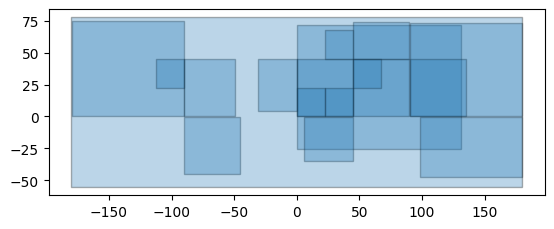

In [12]:
ddf.spatial_partitions.plot(edgecolor='k', alpha=0.3)

# Upload to COS and register in STAC

In [4]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC url
stac_url = os.getenv('stac_url', 'https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com')
# STAC certificate
certificate = os.getenv('certificate', '/opt/app-root/src/ca.cert.txt')

#vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)
bucket

'claimed-test'

In [5]:
# vs.access_key_id = access_key_id
# vs.secret_access_key = secret_access_key
# vs.endpoint_url = endpoint_url
# vs.bucket = bucket
# vs._connect_s3(access_key_id, secret_access_key, endpoint_url, bucket)

# storage_urls = vs.remote_fs.glob(os.path.join(vs.remote_geoparquet_directory, '**.parquet').replace('\\', '/'))
# storage_urls

In [6]:
# # GeoDN username
# geodn_username = os.getenv('geodn_username', '')
# # GeoDN password
# geodn_password = os.getenv('geodn_password', '')
# # GeoDN url
# GEODN_URL = os.getenv('GEODN_URL', "https://openeo-geodn-nasageospatial-dev.cash.sl.cloud9.ibm.com/openeo/1.1.0/")

In [7]:
stac_json_folder = os.path.join(vs.grid_directory, 'stac').replace('\\','/')

bbox = vs.grid.valid_bounds_wgs84
df = pandas.read_parquet(vs.geoparquet_directory, columns=[vs.dt_col])
dt_start = df[vs.dt_col].min()
dt_end = df[vs.dt_col].max()

vs.to_stac_collection(
    stac_url,
    vs.collection_id,
    collection_title,
    stac_json_folder,
    certificate,
    bbox,
    dt_start,
    dt_end,
    description,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
)

In [8]:
%%time
# Upload to COS
upload_type = "replace_all" #"replace_all" "replace_partition" "add" "stac_items_only"
vs.to_cos(
    upload_type=upload_type,
    stac_url=stac_url,
    collection_id=vs.collection_id,
    collection_title=collection_title,
    stac_json_folder=stac_json_folder,
    certificate=certificate,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    endpoint_url=endpoint_url,
    bucket=bucket,
    remote_vectorstore_directory=None,
    temporal_partitions=None,
    spatial_partitions=None,
)

uploading to remote_path claimed-test/vectorstore/rooftop_area_growth_projections/grid=World(4326)/geoparquet/spatial_partition=0q/e390522b0123462aba23096b7f82818d.parquet
schema.names ['FN_ID', 'CF', 'Check', 'BF_X_Y', 'scenario', 'time', 'rooftop area', 'geometry', '_root']
schema.types [DataType(int64), DataType(double), DataType(double), DataType(string), DataType(string), TimestampType(timestamp[ns, tz=UTC]), DataType(double), DataType(binary), DataType(string)]
schema.metadata [b'rooftop_area_growth_projections', b'pandas', b'geo']
uploading to remote_path claimed-test/vectorstore/rooftop_area_growth_projections/grid=World(4326)/geoparquet/spatial_partition=0q012/a54bc388983e4a729ebd3216cb82dbb1.parquet
schema.names ['FN_ID', 'CF', 'Check', 'BF_X_Y', 'scenario', 'time', 'rooftop area', 'geometry', '_root']
schema.types [DataType(int64), DataType(double), DataType(double), DataType(string), DataType(string), TimestampType(timestamp[ns, tz=UTC]), DataType(double), DataType(binary),